
Stanisław Marszałek 160167 </br>
Łukasz Przykłota 159440

In [1]:
from image_processing import read_img,show_img,draw_vessels
import cv2
import numpy as np
import ipywidgets
import torch
from copy import deepcopy

from classic_version import classic_vessel_segmentation

DEVICE:str="cuda" if torch.cuda.is_available() else "cpu"
print(f"USED DEVICE: {DEVICE}")

USED DEVICE: cuda


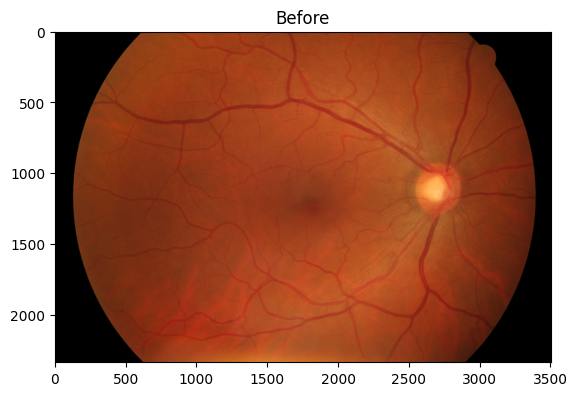

255


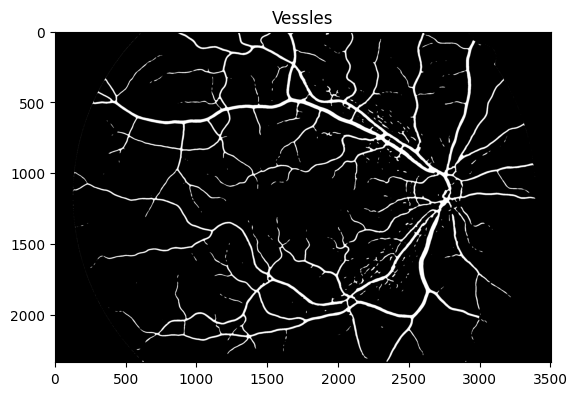

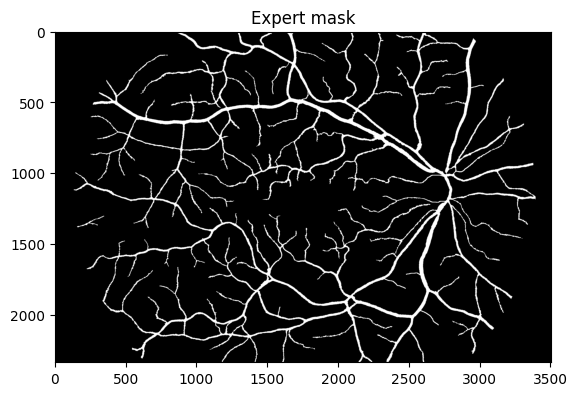

255
1


In [2]:
img=read_img(".\images\\15_h.jpg")
mask=read_img(".\mask\\15_h_mask.tif")
####Trzeba robic kopier origyniały zeby pozniej było do rysowania
img_copy=deepcopy(img)
show_img(img,"Before",False)
print(mask.max())
vessels=classic_vessel_segmentation(img,mask,threshold=0.009)
show_img(vessels,"Vessles")
true_vessels=read_img(".\manual1\\15_h.tif")
show_img(true_vessels,"Expert mask")
print(true_vessels.max())
print(vessels.max())



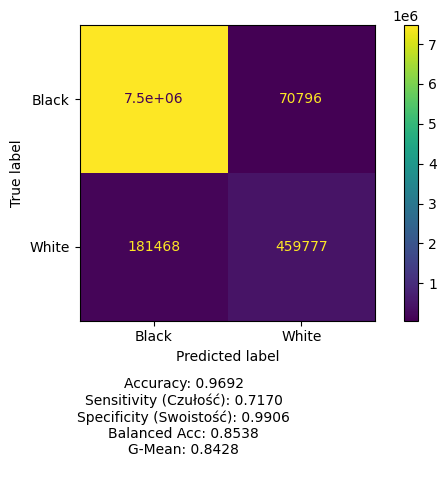

In [3]:
from simple_statistics import create_confusions_matrix
true_vessels=true_vessels[:,:,1]
#Zamiana wartosci z maski z 0 255 na 0 1
true_vessels=np.where(true_vessels>0,1,0)
create_confusions_matrix(true_vessels,vessels)

#print(tn,fp,fn,tp,sep="|")
#print(f"accurac={(tn+tp)/(tn+tp+fp+fn)}")
#print(f"precission={tp/(tp+fn)}")
#print(f"recall={tp/(tp+fp)}")


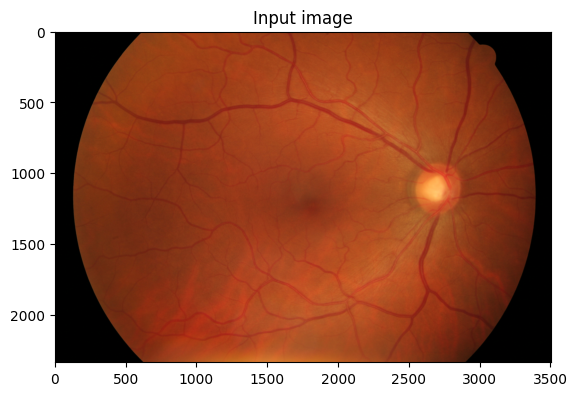

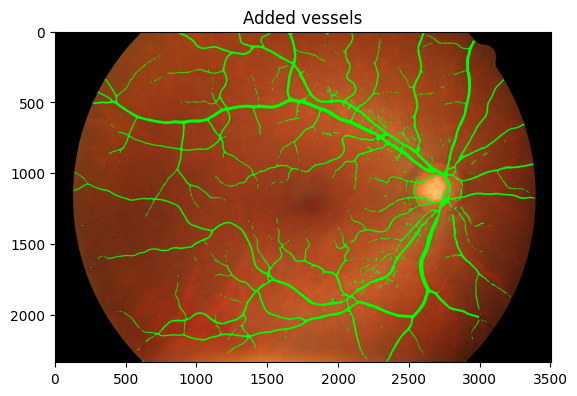

In [4]:
show_img(img_copy,"Input image",False)
img=draw_vessels(img_copy,vessels)
show_img(img,"Added vessels",False)